This notebook loads the saved Rashomon experiment results and performs **basic sanity checks**.

**Purpose**
- Verify shapes and consistency of saved artifacts
- Inspect prediction variance and instability
- Ensure Rashomon composition looks sensible

## 1. Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjust this path to the run you want to inspect
# Path is relative to notebook location (notebooks/ directory)
BASE_PATH = Path("../results/compas/seed=42_eps=0.01")
assert BASE_PATH.exists(), f"Result directory not found: {BASE_PATH.absolute()}"

## 2. Load saved artifacts

In [2]:
P = np.load(BASE_PATH / "P_test.npy")
metrics = np.load(BASE_PATH / "metrics.npz")
meta = pd.read_csv(BASE_PATH / "meta.csv")
X_test = pd.read_csv(BASE_PATH / "X_test.csv")
y_test = np.load(BASE_PATH / "y_test.npy")

## 3. Shape and consistency checks

In [3]:
print("P shape (n_models, n_obs):", P.shape)
print("X_test shape:", X_test.shape)
print("meta shape:", meta.shape)
print("y_test shape:", y_test.shape)

P shape (n_models, n_obs): (24, 1443)
X_test shape: (1443, 5)
meta shape: (24, 4)
y_test shape: (1443,)


In [4]:
assert P.shape[1] == X_test.shape[0] == len(y_test)
assert P.shape[0] == len(meta)

## 4. Inspect Rashomon composition

In [5]:
meta['model_name'].value_counts()

model_name
MLP    14
GBM     9
RF      1
Name: count, dtype: int64

In [6]:
meta['val_loss'].describe()

count    24.000000
mean      0.601018
std       0.002740
min       0.594976
25%       0.599655
50%       0.601671
75%       0.603246
max       0.604714
Name: val_loss, dtype: float64

## 5. Prediction variance diagnostics

In [7]:
v = metrics['variance']

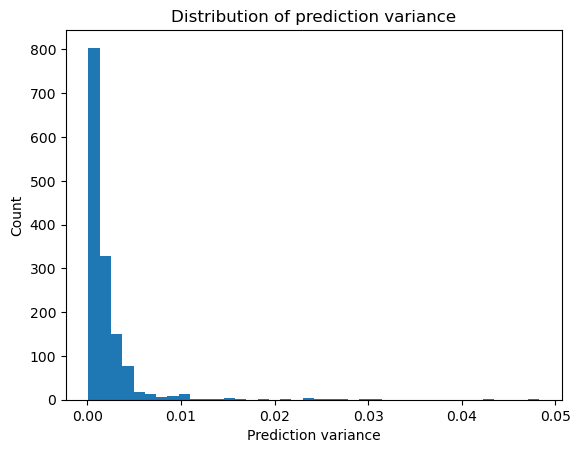

In [8]:
plt.hist(v, bins=40)
plt.xlabel("Prediction variance")
plt.ylabel("Count")
plt.title("Distribution of prediction variance")
plt.show()

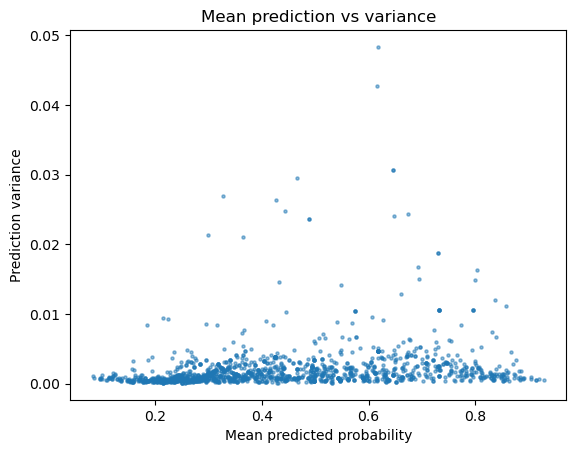

In [9]:
mean_p = P.mean(axis=0)
plt.scatter(mean_p, v, s=5, alpha=0.5)
plt.xlabel("Mean predicted probability")
plt.ylabel("Prediction variance")
plt.title("Mean prediction vs variance")
plt.show()

## 6. Flip instability (decision-relevant)

In [10]:
flip = metrics['flip_instability']

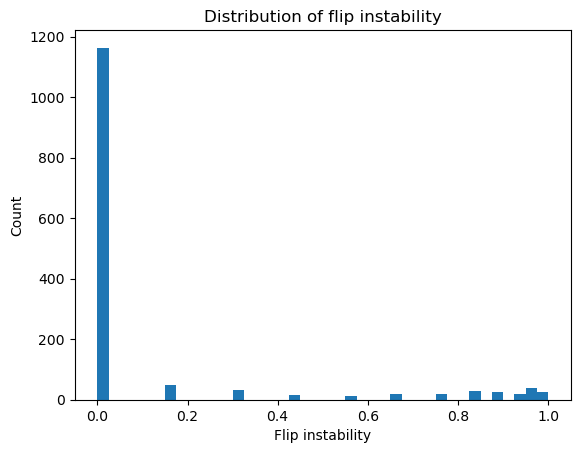

In [11]:
plt.hist(flip, bins=40)
plt.xlabel("Flip instability")
plt.ylabel("Count")
plt.title("Distribution of flip instability")
plt.show()

In [12]:
print("Fraction of points with high flip instability (>0.9):",
      (flip > 0.9).mean())

Fraction of points with high flip instability (>0.9): 0.056133056133056136


## 7. Basic edge-case checks

In [13]:
print("Points with ~zero variance:", (v < 1e-6).sum())
print("Points with max variance:", (v > np.percentile(v, 99)).sum())

Points with ~zero variance: 0
Points with max variance: 14


In [14]:
# Sanity: variance should be zero if only one Rashomon model
if P.shape[0] == 1:
    assert np.allclose(v, 0)

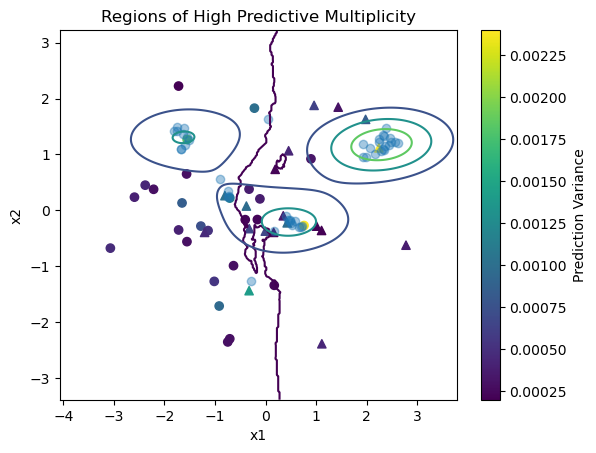

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -----------------------
# Generate toy data
# -----------------------
X, y = make_blobs(n_samples=50, centers=[(-1, 0), (1, 0)],
                  cluster_std=1.2, random_state=42)

np.random.seed(42)
bridge_X = np.random.normal(loc=0, scale=0.7, size=(15, 2))
bridge_y = np.random.randint(0, 2, size=15)

X = np.vstack([X, bridge_X])
y = np.concatenate([y, bridge_y])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------
# Define Rashomon set
# -----------------------
k_values = range(1, 21)
val_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    val_scores.append(accuracy_score(y_val, preds))

val_scores = np.array(val_scores)
best_score = np.max(val_scores)
epsilon = 0.02

rashomon_ks = [k for k, score in zip(k_values, val_scores)
               if score >= best_score - epsilon]

# -----------------------
# Compute variance at training points
# -----------------------
prob_predictions_train = []

for k in rashomon_ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_train)[:, 1]
    prob_predictions_train.append(probs)

prob_predictions_train = np.array(prob_predictions_train)
variance_train = np.var(prob_predictions_train, axis=0)

# -----------------------
# Identify high-variance points
# -----------------------
threshold = np.percentile(variance_train, 80)
high_var_mask = variance_train >= threshold
high_var_points = X_train[high_var_mask]

# -----------------------
# Sample Gaussian perturbations around them
# -----------------------
sigma = 0.2
n_samples_per_point = 30

perturbed_points = []

for x in high_var_points:
    noise = np.random.normal(0, sigma, size=(n_samples_per_point, 2))
    perturbed_points.append(x + noise)

perturbed_points = np.vstack(perturbed_points)

# -----------------------
# Compute variance at perturbed points
# -----------------------
prob_predictions_perturbed = []

for k in rashomon_ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    probs = model.predict_proba(perturbed_points)[:, 1]
    prob_predictions_perturbed.append(probs)

prob_predictions_perturbed = np.array(prob_predictions_perturbed)
variance_perturbed = np.var(prob_predictions_perturbed, axis=0)

# -----------------------
# Compute mean decision boundary
# -----------------------
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

prob_predictions_grid = []

for k in rashomon_ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    probs = model.predict_proba(grid)[:, 1]
    prob_predictions_grid.append(probs)

prob_predictions_grid = np.array(prob_predictions_grid)
mean_prob_grid = np.mean(prob_predictions_grid, axis=0)
mean_prob_grid = mean_prob_grid.reshape(xx.shape)

# -----------------------
# Plot
# -----------------------
plt.figure()

# Mean decision boundary
plt.contour(xx, yy, mean_prob_grid, levels=[0.5])

# Training points (colored by variance, different markers per class)
class0 = y_train == 0
class1 = y_train == 1

sc0 = plt.scatter(X_train[class0, 0], X_train[class0, 1],
                  c=variance_train[class0],
                  marker='o')

sc1 = plt.scatter(X_train[class1, 0], X_train[class1, 1],
                  c=variance_train[class1],
                  marker='^')

# Perturbed points (faint)
tau = np.percentile(variance_train, 95)
high_var_perturbed = variance_perturbed > tau

plt.scatter(perturbed_points[high_var_perturbed, 0],
            perturbed_points[high_var_perturbed, 1],
            alpha=0.4)


plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Regions of High Predictive Multiplicity")
plt.colorbar(sc0, label="Prediction Variance")

from scipy.stats import gaussian_kde

xy = perturbed_points[high_var_perturbed].T
kde = gaussian_kde(xy)

z = kde(np.vstack([xx.ravel(), yy.ravel()]))
z = z.reshape(xx.shape)

plt.contour(xx, yy, z, levels=3)
plt.show()

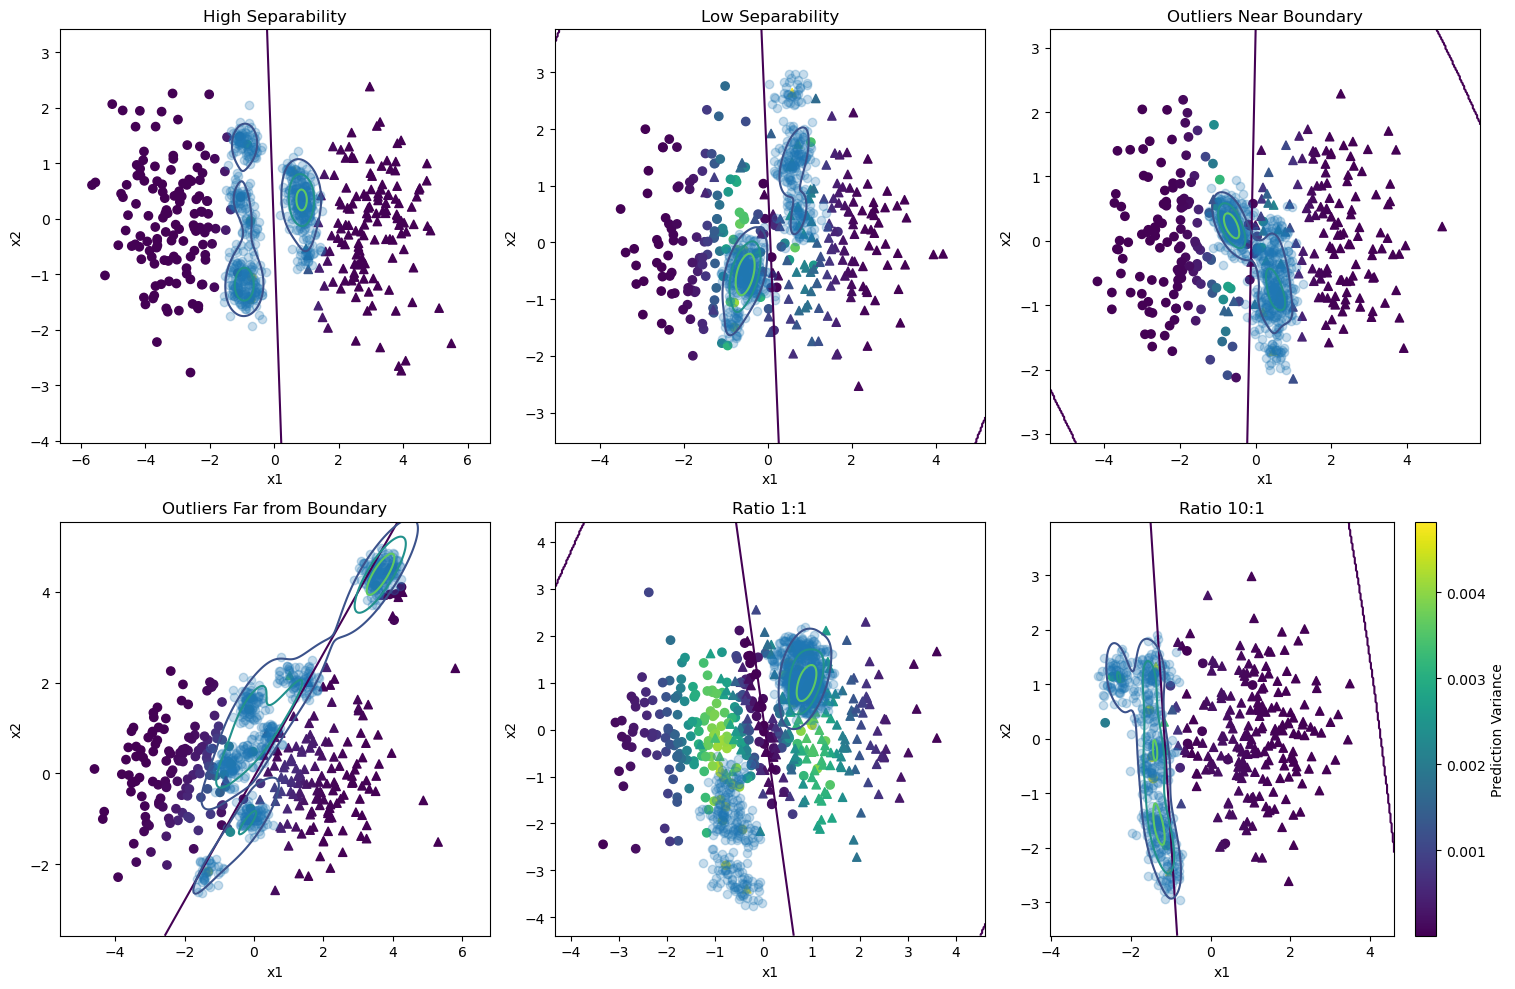

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from scipy.stats import gaussian_kde

# --------------------------------------------------
# Helper: Rashomon variance + mean boundary
# --------------------------------------------------
def rashomon_variance(X, y, epsilon=0.02):

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    Cs = np.logspace(-2, 2, 25)
    models = []
    losses = []

    for C in Cs:
        model = LogisticRegression(C=C, solver="lbfgs")
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]
        losses.append(log_loss(y_val, probs))
        models.append(model)

    losses = np.array(losses)
    best_loss = np.min(losses)

    rashomon_models = [
        m for m, l in zip(models, losses)
        if l <= best_loss + epsilon
    ]

    # Variance at training points
    prob_train = []
    for m in rashomon_models:
        prob_train.append(m.predict_proba(X_train)[:, 1])
    prob_train = np.array(prob_train)
    variance_train = np.var(prob_train, axis=0)

    # Mean boundary
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    prob_grid = []
    for m in rashomon_models:
        prob_grid.append(m.predict_proba(grid)[:, 1])
    prob_grid = np.array(prob_grid)
    mean_prob = np.mean(prob_grid, axis=0).reshape(xx.shape)

    return X_train, y_train, variance_train, xx, yy, mean_prob


# --------------------------------------------------
# Synthetic generators
# --------------------------------------------------
def generate_separable(sep):
    mean1 = [-sep, 0]
    mean2 = [sep, 0]
    cov = [[1, 0], [0, 1]]
    X1 = np.random.multivariate_normal(mean1, cov, 200)
    X2 = np.random.multivariate_normal(mean2, cov, 200)
    X = np.vstack([X1, X2])
    y = np.concatenate([np.zeros(200), np.ones(200)])
    return X, y


def generate_outliers(near=True):
    X, y = generate_separable(2)
    if near:
        out = np.random.normal(loc=[0, 0], scale=0.3, size=(20, 2))
    else:
        out = np.random.normal(loc=[4, 4], scale=0.3, size=(20, 2))
    labels = np.random.randint(0, 2, 20)
    X = np.vstack([X, out])
    y = np.concatenate([y, labels])
    return X, y


def generate_imbalance(ratio):
    n_major = 300
    n_minor = int(n_major / ratio)
    mean_major = [1, 0]
    mean_minor = [-1, 0]
    cov = [[1, 0], [0, 1]]
    X_major = np.random.multivariate_normal(mean_major, cov, n_major)
    X_minor = np.random.multivariate_normal(mean_minor, cov, n_minor)
    X = np.vstack([X_major, X_minor])
    y = np.concatenate([np.ones(n_major), np.zeros(n_minor)])
    return X, y


# --------------------------------------------------
# All six experiments
# --------------------------------------------------
np.random.seed(0)

experiments = [
    ("High Separability", generate_separable(3)),
    ("Low Separability", generate_separable(1.5)),
    ("Outliers Near Boundary", generate_outliers(True)),
    ("Outliers Far from Boundary", generate_outliers(False)),
    ("Ratio 1:1", generate_imbalance(1)),
    ("Ratio 10:1", generate_imbalance(10)),
]

plt.figure(figsize=(15, 10))

for i, (title, (X, y)) in enumerate(experiments):

    X_train, y_train, variance_train, xx, yy, mean_prob = \
        rashomon_variance(X, y)

    tau = np.percentile(variance_train, 95)
    high_var_mask = variance_train >= tau
    high_var_points = X_train[high_var_mask]

    sigma = 0.2
    n_samples = 40
    perturbed = []

    for x in high_var_points:
        noise = np.random.normal(0, sigma, size=(n_samples, 2))
        perturbed.append(x + noise)

    if len(perturbed) > 0:
        perturbed = np.vstack(perturbed)
    else:
        perturbed = np.empty((0, 2))

    plt.subplot(2, 3, i + 1)

    # Mean decision boundary
    plt.contour(xx, yy, mean_prob, levels=[0.5])

    # Training points
    class0 = y_train == 0
    class1 = y_train == 1

    sc = plt.scatter(X_train[class0, 0],
                     X_train[class0, 1],
                     c=variance_train[class0],
                     marker='o')

    plt.scatter(X_train[class1, 0],
                X_train[class1, 1],
                c=variance_train[class1],
                marker='^')

    # Perturbed region
    if len(perturbed) > 0:
        plt.scatter(perturbed[:, 0],
                    perturbed[:, 1],
                    alpha=0.25)

        xy = perturbed.T
        kde = gaussian_kde(xy)
        z = kde(np.vstack([xx.ravel(), yy.ravel()]))
        z = z.reshape(xx.shape)
        plt.contour(xx, yy, z, levels=3)

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

plt.tight_layout()
plt.colorbar(sc, label="Prediction Variance")
plt.show()


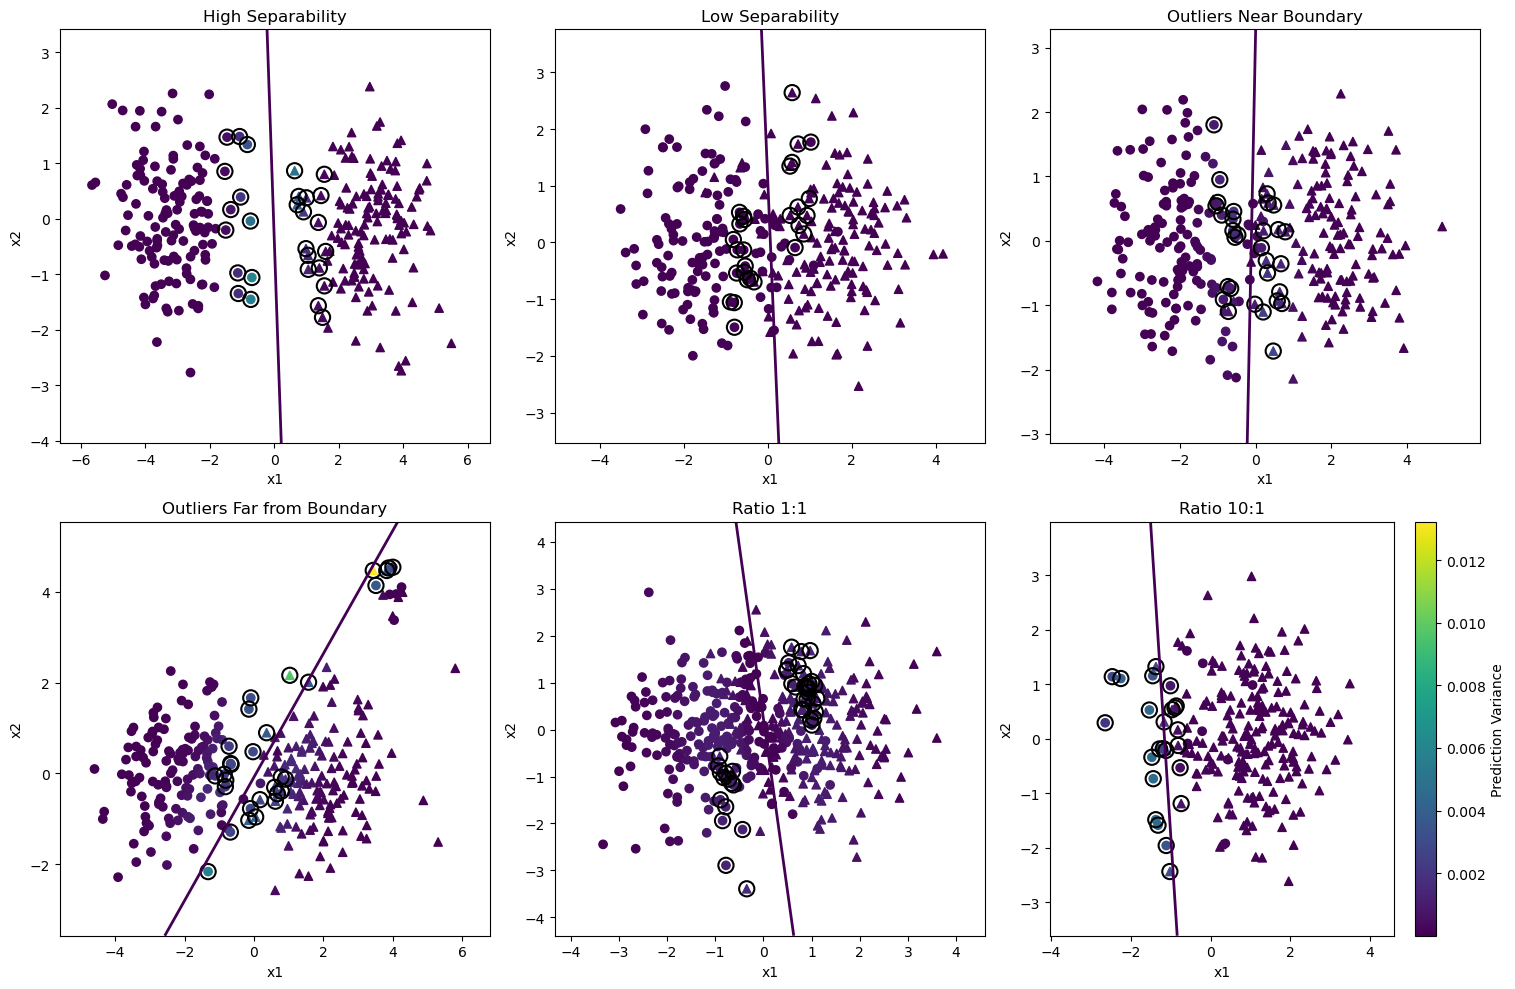

In [36]:
# --------------------------------------------------
# Precompute global variance scale
# --------------------------------------------------

all_variances = []

for title, (X, y) in experiments:
    X_train, y_train, variance_train, xx, yy, mean_prob = \
        rashomon_variance(X, y)
    all_variances.append(variance_train)

global_vmin = min(v.min() for v in all_variances)
global_vmax = max(v.max() for v in all_variances)


# --------------------------------------------------
# Plot All 6 (Improved Visualization)
# --------------------------------------------------

plt.figure(figsize=(15, 10))

for i, (title, (X, y)) in enumerate(experiments):

    X_train, y_train, variance_train, xx, yy, mean_prob = \
        rashomon_variance(X, y)

    tau = np.percentile(variance_train, 90)
    high_var_mask = variance_train >= tau
    high_var_points = X_train[high_var_mask]

    plt.subplot(2, 3, i + 1)

    # Mean decision boundary
    plt.contour(xx, yy, mean_prob, levels=[0.5], linewidths=2)

    # Training points (class shapes)
    class0 = y_train == 0
    class1 = y_train == 1

    sc = plt.scatter(
        X_train[class0, 0],
        X_train[class0, 1],
        c=variance_train[class0],
        marker='o',
        vmin=global_vmin,
        vmax=global_vmax
    )

    plt.scatter(
        X_train[class1, 0],
        X_train[class1, 1],
        c=variance_train[class1],
        marker='^',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # Highlight only high variance region
    if len(high_var_points) > 0:
        plt.scatter(
            high_var_points[:, 0],
            high_var_points[:, 1],
            edgecolor='black',
            facecolor='none',
            s=120,
            linewidth=1.5
        )

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

plt.tight_layout()
plt.colorbar(sc, label="Prediction Variance")
plt.show()
